In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy.stats import norm
from sklearn import mixture
import random

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

#import itertools
#from concurrent.futures import ThreadPoolExecutor, as_completed
from joblib import delayed, Parallel
from tqdm import tqdm
import pickle

In [2]:
flowers = flowers = ['rose','orchid','tulip','lily','sunflower','lotus','peony','hydrangea','dahlia','magnolia','iris','gardenia','poppy','hyacinth','wisteria','daffodil','daisy','chrysanthemum','lavender','carnation','marigold','hibiscus','bluebell','zinnia','anemone','azalea','calla lily','cherry blossom','bird of paradise','gerbera daisy']
def findname(text):
    ans = -1
    IDs = []; Locations = []
    for i in flowers:
        if i in text.lower():
            IDs.append(flowers.index(i))
            Locations.append(text.find(i))
    if len(IDs)>0:
        ans = IDs[np.argmin(Locations)]
    return ans

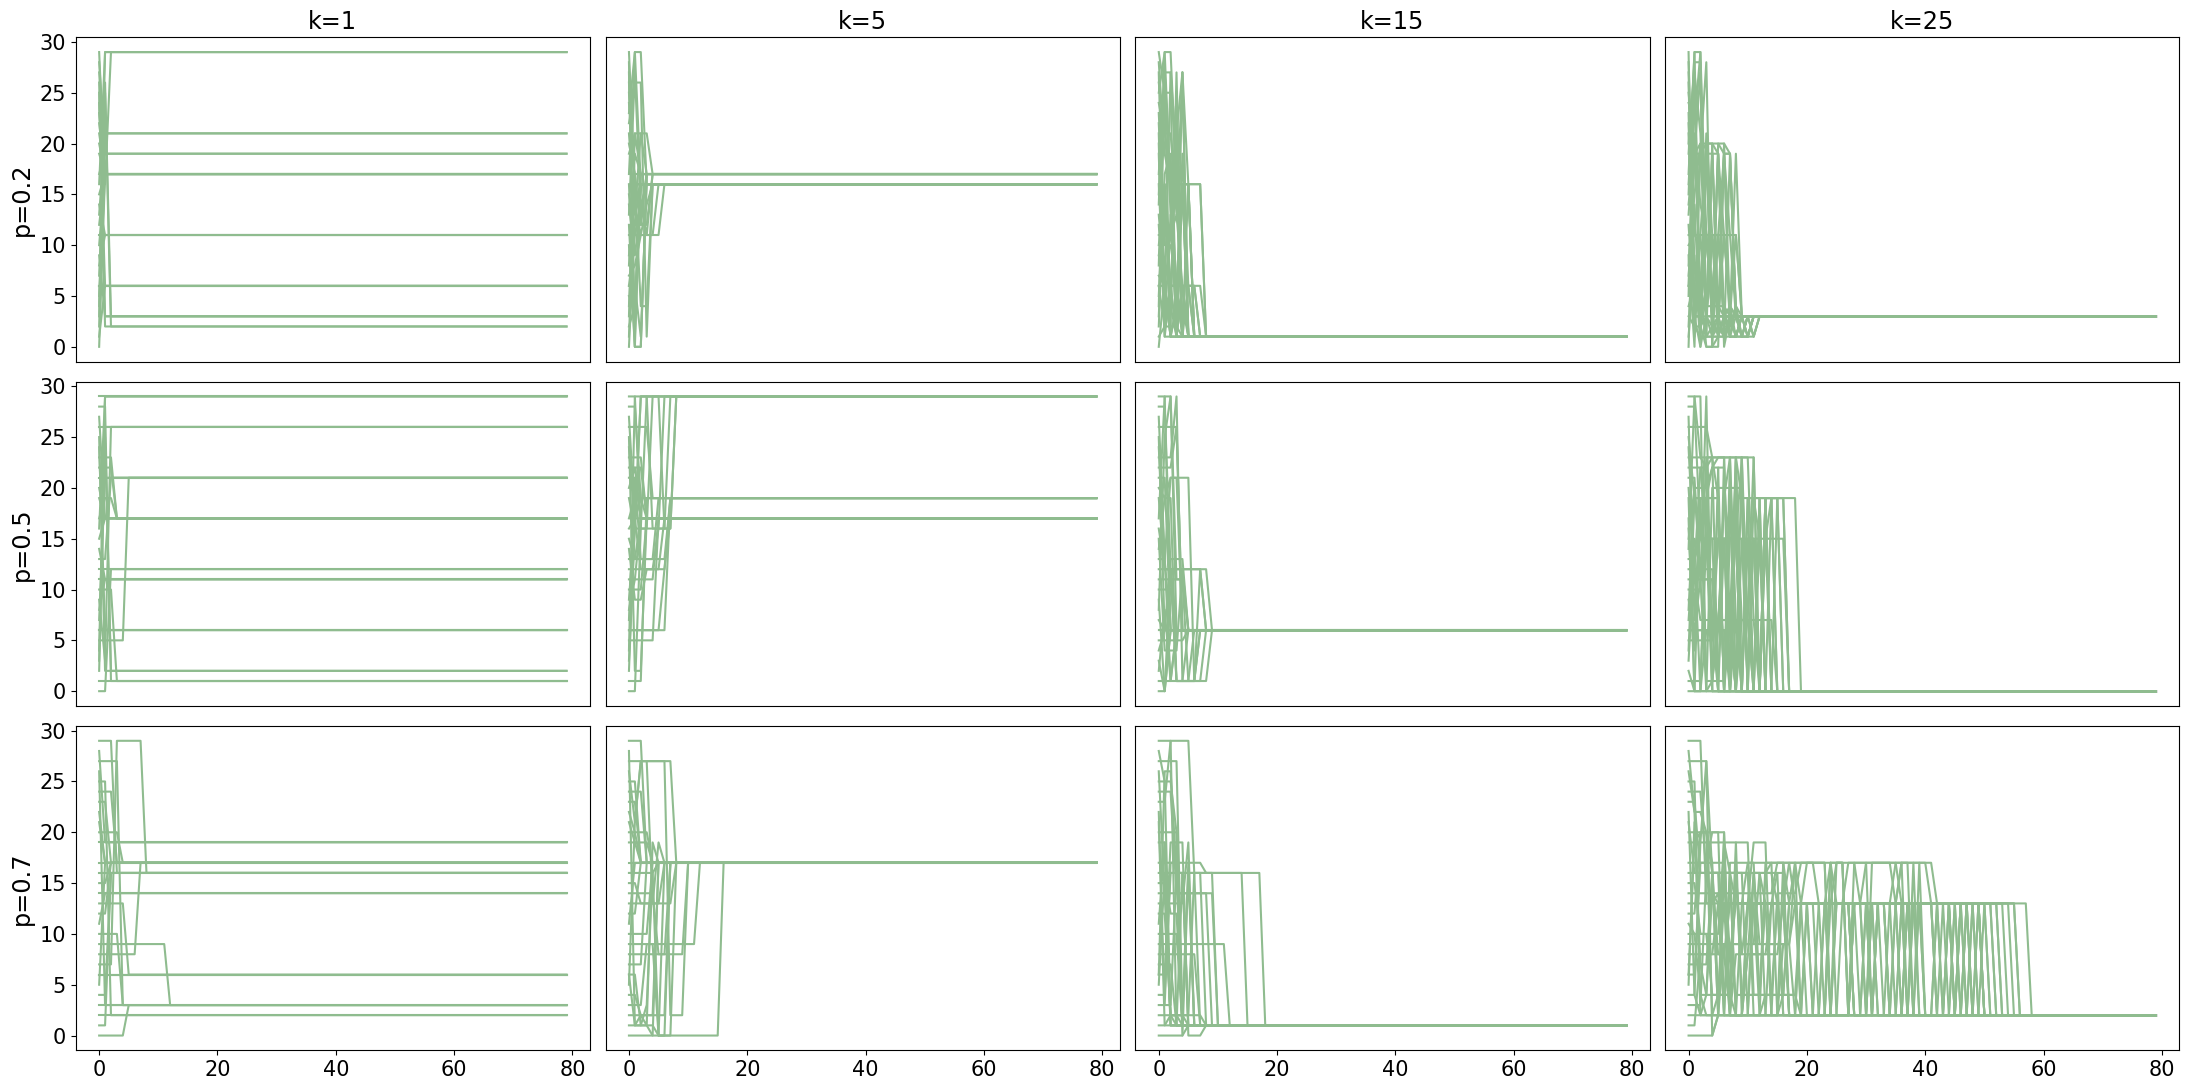

In [4]:
#part1[30] = {0.3 if k == 0.30000000000000004 else k:v for k,v in part1[30].items()}
#print(part1[30].keys())
#print(part2[30].keys())

rows = [0.2, 0.5, 0.7]
cols = [1, 5, 15, 25]
n=30
T=80

fig, axs = plt.subplots(len(rows), len(cols), figsize=(22,11))
v=1
for pidx, p in enumerate(rows):
    for kidx, k in enumerate(cols):
        df = pd.read_csv('RawData/output'+str(int(p*10))+'_'+str(k)+'_'+str(v)+'.csv')
        df2 = pd.read_csv('RawData/output'+str(int(p*10))+'_'+str(k)+'_'+str(v)+'_2nd.csv')
        df = pd.concat([df[:40],df2])
        I = []
        for i in range(0,n):
            It = []
            for t in range(T):
                It.append(findname(df.iloc[t,i+1]))
            I.append(It)
        dfi = pd.DataFrame(np.transpose(I))
        dfi.plot(y=dfi.columns, ax = axs[pidx, kidx], title=f'', color=['darkseagreen']*30, legend=False, xlabel='', ylabel='')
        if pidx != len(rows)-1:
            axs[pidx, kidx].get_xaxis().set_ticks([])
        if kidx != 0:
            axs[pidx, kidx].get_yaxis().set_ticks([])
        axs[pidx, kidx].get_xaxis().set_tick_params(labelsize=15)
        axs[pidx, kidx].get_yaxis().set_tick_params(labelsize=15)
for ax, col in zip(axs[0], cols):
    ax.set_title(f'k={col}', size='xx-large')
for ax, row in zip(axs[:,0], rows):
    ax.set_ylabel(f'p={row}', size='xx-large')


fig.tight_layout()
plt.savefig('sweep.png')